# Korelasi Fitur dan Target

Heatmap korelasi antara fitur sensor/sensorik dengan target pada Dataset Teh Hijau.
Target bisa diganti lewat variabel `TARGET` (mis. `"Kategori"` atau `"Standar Kualitas"`).

Catatan:
- Target kategorikal di-encode ordinal mengikuti urutan alfabet nilai uniknya.
  - `Kategori` A–E → 0…4 (jenjang kualitas).
  - `Standar Kualitas` (`Baik`, `Cacat Mutu`) → 0, 1.
- `Chop_ID` & `Sampling_ID` adalah label **nominal** → di-encode sebagai kode integer.
- Korelasi memakai metode **Spearman** karena target ordinal dan banyak hubungan non-linear/monoton.

⚠️ `Chop_ID`/`Sampling_ID` hanya kode urutan ID — korelasinya bisa menyesatkan dan terkait isu kebocoran data ber-grup. Jangan dijadikan fitur model.

In [13]:
import sys
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())
project_root = Path(os.environ["PROJECT_ROOT"])
print(f"Project root: {project_root}")

sys.path.append(os.path.abspath(project_root))

Project root: c:\`Bioinformatics\quantum-gesang\codes


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_PATH = project_root / "dataset" / "Dataset_TehHijau.csv"

# Daftar fitur (JANGAN masukkan kolom target di sini).
FEATURES = [
    "MQ3", "TGS822", "TGS2602", "MQ5", "MQ138", "TGS2620", "TGS813",
    "TGS2600", "TGS2611", "TGS2603", "Humidity", "Celsius",
    "Chop_ID", "Sampling_ID", "Aroma", "Taste", "Color", "Appearance", "Dreg",
]

# Ganti target di sini: "Kategori" atau "Standar Kualitas".
TARGET = "Standar Kualitas"

# Kolom nominal yang perlu di-encode integer (jika dipakai sebagai fitur).
NOMINAL_COLS = ["Chop_ID", "Sampling_ID"]

df = pd.read_csv(DATA_PATH)

# Buang target dari FEATURES kalau tidak sengaja ikut, supaya tidak ada kolom dobel.
feature_cols = [c for c in FEATURES if c != TARGET]
data = df[feature_cols + [TARGET]].copy()
data.shape

(10409, 20)

In [15]:
# Encode target kategorikal menjadi ordinal (urut alfabet nilai unik).
cat_order = sorted(data[TARGET].dropna().unique())
print("Urutan kategori target:", cat_order)
data[TARGET] = data[TARGET].map({c: i for i, c in enumerate(cat_order)})

# Chop_ID & Sampling_ID adalah label nominal -> kode integer.
for col in NOMINAL_COLS:
    if col in data.columns:
        data[col] = data[col].astype("category").cat.codes

Urutan kategori target: ['Baik', 'Cacat Mutu']


Heatmap disimpan ke: c:\`Bioinformatics\quantum-gesang\codes\dataset\korelasi_fitur_standar_kualitas.png


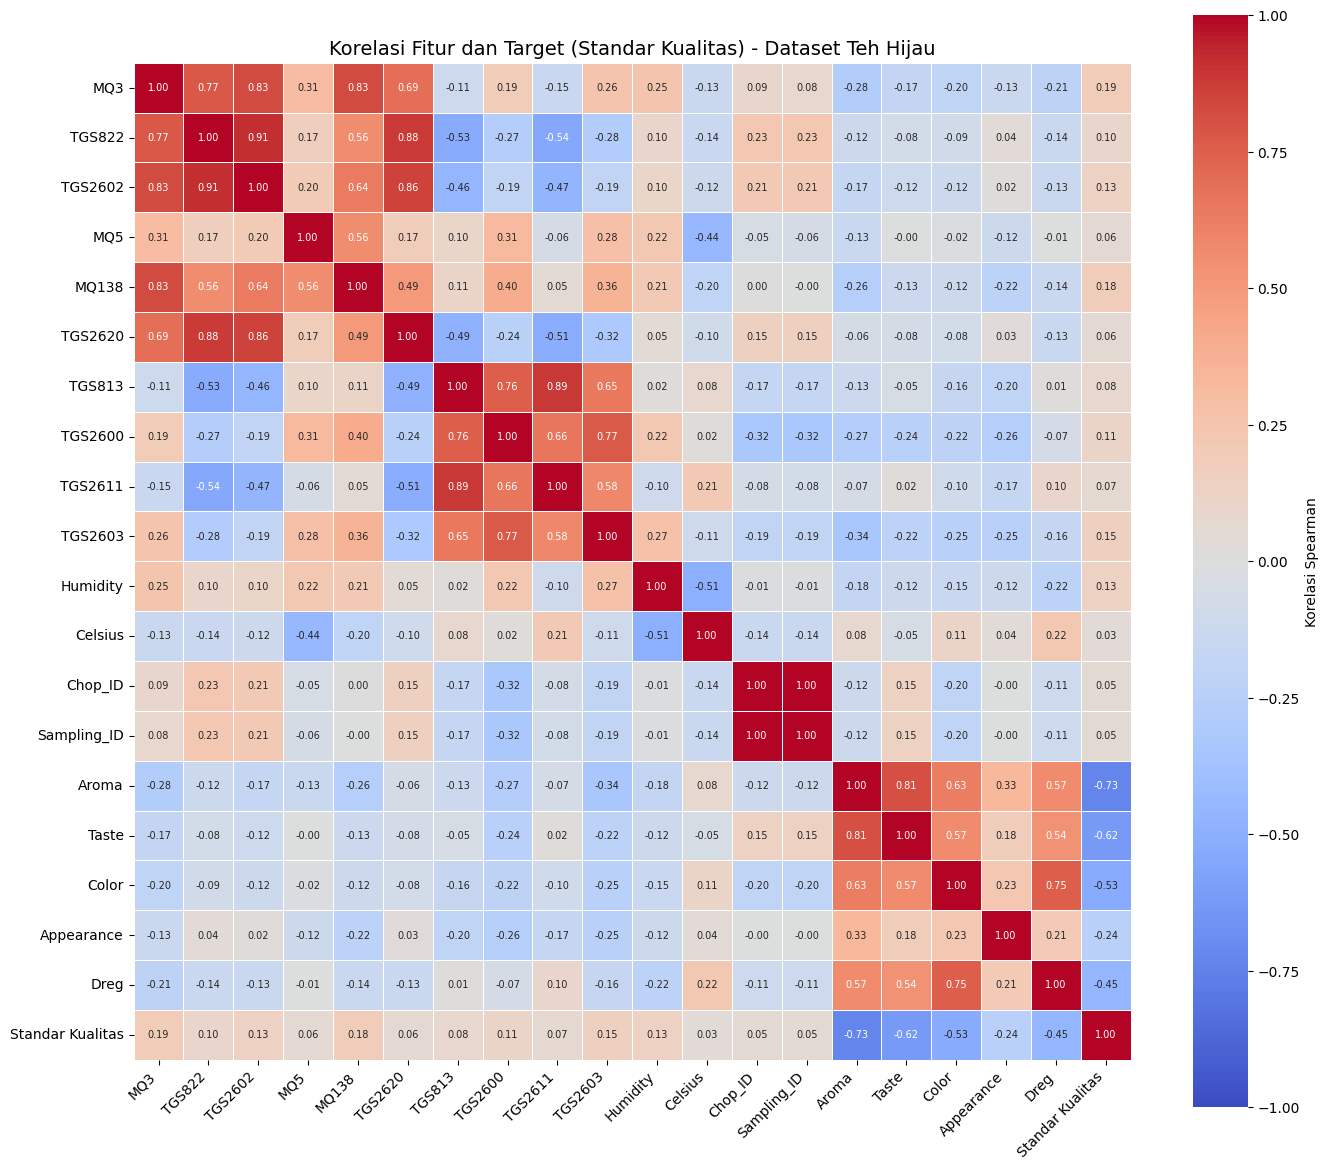

In [16]:
# Spearman: robust untuk hubungan monoton & data ordinal.
corr = data.corr(method="spearman")

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Korelasi Spearman"},
    annot_kws={"size": 7},
)
plt.title(f"Korelasi Fitur dan Target ({TARGET}) - Dataset Teh Hijau", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

safe_target = TARGET.lower().replace(' ', '_')
OUT_PATH = project_root / "dataset" / f"korelasi_fitur_{safe_target}.png"
plt.savefig(OUT_PATH, dpi=150, bbox_inches="tight")
print(f"Heatmap disimpan ke: {OUT_PATH}")
plt.show()

In [17]:
# Korelasi tiap fitur terhadap target, urut |nilai| terbesar.
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
target_corr.to_frame("spearman_corr")

,spearman_corr
Aroma,-0.729275
Taste,-0.619613
Color,-0.530343
Dreg,-0.454086
Appearance,-0.242575
MQ3,0.190515
MQ138,0.178466
TGS2603,0.149488
TGS2602,0.133167
Humidity,0.133006
